# Medicare Denial Intelligence — Exploratory Data Analysis

Explores dbt **marts** built from CMS Medicare public data:

- `public_marts.dim_providers`
- `public_marts.fct_provider_spending`
- `public_marts.fct_utilization_by_specialty`

**Prerequisites:** Docker Postgres running, marts built (`dbt run --select marts`).

Set `POSTGRES_HOST=localhost` in `.env` when running locally.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
load_dotenv(PROJECT_ROOT / ".env")

import os

engine = create_engine(
    "postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}".format(
        user=os.getenv("POSTGRES_USER", "denial_user"),
        password=os.getenv("POSTGRES_PASSWORD", ""),
        host=os.getenv("POSTGRES_HOST", "localhost"),
        port=os.getenv("POSTGRES_PORT", "5432"),
        db=os.getenv("POSTGRES_DB", "denial_db"),
    )
)


def q(sql: str, **params) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn, params=params)

sns.set_theme(style="whitegrid")
pd.options.display.float_format = lambda x: f"{x:,.4f}"

## 1. Dataset overview

In [3]:
overview = q("""
SELECT 'dim_providers' AS table_name, COUNT(*) AS row_count
FROM public_marts.dim_providers
UNION ALL
SELECT 'fct_provider_spending', COUNT(*)
FROM public_marts.fct_provider_spending
UNION ALL
SELECT 'fct_utilization_by_specialty', COUNT(*)
FROM public_marts.fct_utilization_by_specialty
""")
overview

,table_name,row_count
0,dim_providers,9606683
1,fct_provider_spending,54818770
2,fct_utilization_by_specialty,9996


## 2. Implied withhold rate by specialty

Withhold rate = `1 - (Medicare payment / allowed amount)` — used here as a **denial proxy** when line-level denial codes are unavailable in public CMS files.

In [4]:
specialty = q("""
SELECT
    specialty,
    year,
    SUM(provider_count) AS providers,
    SUM(service_line_count) AS service_lines,
    ROUND(AVG(avg_withhold_rate)::numeric, 4) AS avg_withhold_rate,
    ROUND(AVG(median_withhold_rate)::numeric, 4) AS median_withhold_rate
FROM public_marts.fct_utilization_by_specialty
WHERE specialty <> 'Unknown'
GROUP BY specialty, year
ORDER BY avg_withhold_rate DESC
LIMIT 20
""")
specialty

,specialty,year,providers,service_lines,avg_withhold_rate,median_withhold_rate
0,Optometry,2024,"30,060.0000","181,256.0000",0.3331,0.3289
1,Optometry,2023,"29,720.0000","177,558.0000",0.3322,0.3279
2,Chiropractic,2024,"31,446.0000","41,091.0000",0.3101,0.3033
3,Chiropractic,2023,"32,225.0000","42,438.0000",0.3059,0.3007
4,Audiologist,2024,"7,511.0000","22,985.0000",0.3013,0.2954
5,Audiologist,2023,"7,289.0000","22,229.0000",0.2966,0.2909
6,Maxillofacial Surgery,2023,507.0000,"1,350.0000",0.2878,0.2775
7,Ophthalmology,2024,"17,025.0000","227,753.0000",0.2813,0.2717
8,Ophthalmology,2023,"17,001.0000","225,821.0000",0.2805,0.2716
9,Oral Surgery (Dentist only),2024,702.0000,"2,283.0000",0.2756,0.2658


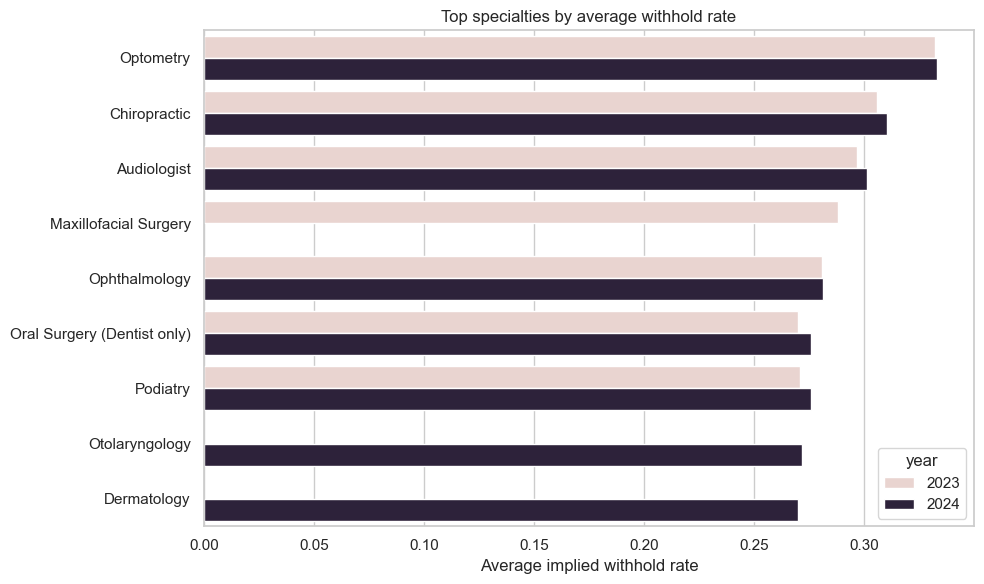

In [5]:
plot_df = specialty.head(15).copy()
plot_df["label"] = plot_df["specialty"].str.slice(0, 40)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_df, y="label", x="avg_withhold_rate", hue="year", ax=ax)
ax.set_xlabel("Average implied withhold rate")
ax.set_ylabel("")
ax.set_title("Top specialties by average withhold rate")
plt.tight_layout()
plt.show()

## 3. Geographic variation (state × year)

In [6]:
by_state = q("""
SELECT
    state,
    year,
    ROUND(AVG(avg_withhold_rate)::numeric, 4) AS avg_withhold_rate,
    SUM(provider_count) AS providers
FROM public_marts.fct_utilization_by_specialty
WHERE state <> 'Unknown'
GROUP BY state, year
ORDER BY avg_withhold_rate DESC
LIMIT 15
""")
by_state

,state,year,avg_withhold_rate,providers
0,GALIL,2023,0.4299,1.0000
1,VIRGINIA,2023,0.3947,1.0000
2,MARYLAND,2024,0.3753,1.0000
3,HAMILTON,2024,0.3566,1.0000
4,RAMSTEIN-MIESENBACH,2023,0.3417,1.0000
5,NEW MEXICO,2024,0.3296,1.0000
6,MARYLAND,2023,0.3281,1.0000
7,TENNESSEE,2024,0.3268,2.0000
8,KUNSAN,2024,0.3119,1.0000
9,ISRAEL,2024,0.3078,1.0000


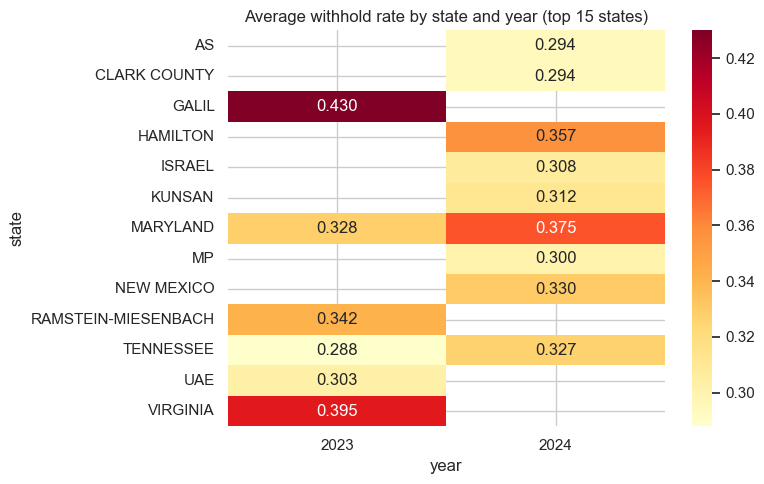

In [7]:
pivot = by_state.pivot(index="state", columns="year", values="avg_withhold_rate")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Average withhold rate by state and year (top 15 states)")
plt.tight_layout()
plt.show()

## 4. Part D drug spending concentration

In [8]:
top_drugs = q("""
SELECT
    COALESCE(drug_name, generic_name, 'Unknown') AS drug,
    year,
    COUNT(DISTINCT npi) AS prescriber_count,
    SUM(total_claim_count) AS claims,
    ROUND(SUM(total_drug_cost)::numeric, 2) AS total_medicare_cost
FROM public_marts.fct_provider_spending
GROUP BY 1, 2
ORDER BY total_medicare_cost DESC
LIMIT 20
""")
top_drugs

,drug,year,prescriber_count,claims,total_medicare_cost
0,Eliquis,2024,264286,22996543,"19,876,304,796.0200"
1,Eliquis,2023,245552,20163420,"17,392,162,956.0700"
2,Ozempic,2024,171191,9930484,"12,375,986,474.9500"
3,Jardiance,2024,198275,10654599,"10,678,957,371.7200"
4,Ozempic,2023,131910,6416007,"8,535,565,766.4700"
5,Jardiance,2023,160206,7460553,"8,031,744,087.3100"
6,Trulicity,2023,109569,4851616,"6,666,365,125.9000"
7,Mounjaro,2024,97208,4694896,"5,825,295,740.7300"
8,Xarelto,2023,132410,5892811,"5,511,694,348.0100"
9,Xarelto,2024,134291,5888827,"5,436,701,738.5000"


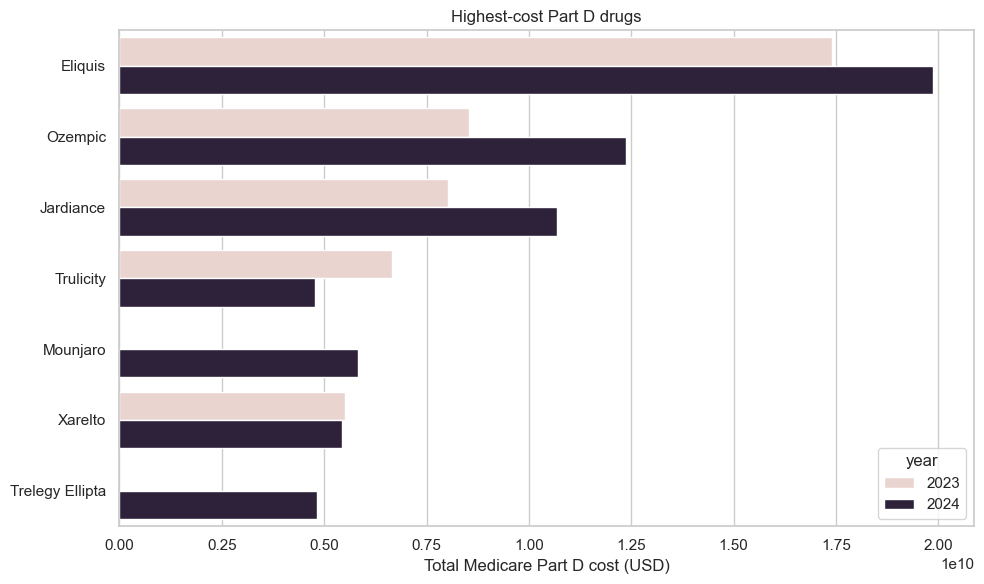

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_drugs = top_drugs.head(12).copy()
plot_drugs["label"] = plot_drugs["drug"].str.slice(0, 35)
sns.barplot(
    data=plot_drugs,
    y="label",
    x="total_medicare_cost",
    hue="year",
    ax=ax,
)
ax.set_xlabel("Total Medicare Part D cost (USD)")
ax.set_ylabel("")
ax.set_title("Highest-cost Part D drugs")
plt.tight_layout()
plt.show()

## 5. Provider dimension snapshot

In [10]:
provider_mix = q("""
SELECT
    entity_type_label,
    state,
    COUNT(*) AS provider_count
FROM public_marts.dim_providers
WHERE state IS NOT NULL
GROUP BY entity_type_label, state
ORDER BY provider_count DESC
LIMIT 15
""")
provider_mix

,entity_type_label,state,provider_count
0,individual,CA,966277
1,individual,NY,547234
2,individual,FL,471284
3,individual,TX,432156
4,individual,OH,335558
5,individual,MI,285445
6,individual,PA,261902
7,individual,IL,240785
8,individual,MA,219375
9,individual,WA,203839


## 6. ML feature preview (next step)

A future classifier can label providers/service lines with **high withhold risk** using features such as:

- specialty, state, place of service
- average allowed vs. paid amounts
- claim volume and beneficiary counts

Target idea: `high_withhold = implied_withhold_rate > specialty_median` at the provider level.

In [ ]:
ml_preview = q("""
WITH provider_rates AS (
    SELECT
        u.npi,
        u.cms_specialty,
        u.provider_state,
        u.year,
        AVG(u.implied_withhold_rate) AS avg_withhold_rate,
        COUNT(*) AS service_lines
    FROM public_intermediate.int_utilization_enriched u
    WHERE u.implied_withhold_rate IS NOT NULL
    GROUP BY 1, 2, 3, 4
),
specialty_medians AS (
    SELECT
        cms_specialty,
        year,
        percentile_cont(0.5) WITHIN GROUP (ORDER BY avg_withhold_rate) AS specialty_median
    FROM provider_rates
    GROUP BY 1, 2
)
SELECT
    p.npi,
    p.cms_specialty,
    p.provider_state,
    p.year,
    ROUND(p.avg_withhold_rate::numeric, 4) AS avg_withhold_rate,
    ROUND(s.specialty_median::numeric, 4) AS specialty_median,
    CASE WHEN p.avg_withhold_rate > s.specialty_median THEN 1 ELSE 0 END AS high_withhold_flag,
    p.service_lines
FROM provider_rates p
JOIN specialty_medians s
  ON p.cms_specialty = s.cms_specialty
 AND p.year = s.year
ORDER BY p.avg_withhold_rate DESC
LIMIT 20
""")
ml_preview